In [1]:
"数据集的下载"

import hashlib
import os
import tarfile
import zipfile
import requests

# 数据集统一托管的云根路径
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'
DATA_HUB = dict()
rootpath = "C:/Users/17934/Desktop/MachineLearning/Program/Kaggle_Exercise/DATA"

def download(name, cache_dir=os.path.join('..', 'data')):
    """
    从DATA_HUB下载数据集，本地缓存复用
    param name: DATA_HUB中注册的数据集名称
    param cache_dir: 本地缓存文件夹，默认 ../data
    return: 本地缓存压缩包完整路径
    """

    # 校验数据集是否已注册，不存在直接报错
    assert name in DATA_HUB, f"数据集 [{name}] 未在DATA_HUB中注册！"
    # 取出该数据集的云端路径、标准哈希值
    relative_url, standard_sha1 = DATA_HUB[name]
    full_url = DATA_URL + relative_url

    # 创建缓存目录，exist_ok=True：目录已存在不会报错
    os.makedirs(cache_dir, exist_ok=True)
    # 截取url末尾文件名，拼接成本地完整缓存路径
    file_name = full_url.split('/')[-1]
    local_file_path = os.path.join(cache_dir, file_name)

    # ========== 缓存命中逻辑：本地存在文件则校验哈希 ==========
    if os.path.exists(local_file_path):
        # 创建sha1哈希计算器
        sha1_calc = hashlib.sha1()
        # 二进制只读打开文件，分块读取（每次1MB，防止大文件占满内存）
        with open(local_file_path, 'rb') as f:
            while True:
                chunk = f.read(1048576)  # 1048576 byte = 1MB
                if not chunk:
                    break
                sha1_calc.update(chunk)
        # 对比计算出的哈希 和 官方标准哈希
        file_sha1 = sha1_calc.hexdigest()
        if file_sha1 == standard_sha1:
            print(f"缓存命中：复用本地文件 {local_file_path}")
            return local_file_path
        else:
            print(f"本地文件哈希不匹配，文件损坏/版本错误，重新下载...")

    # ========== 缓存失效/无本地文件：发起网络下载 ==========
    print(f"开始下载数据集：{full_url} -> {local_file_path}")
    # stream=True 流式下载，不一次性把整个文件载入内存
    response = requests.get(full_url, stream=True, verify=True)
    # 二进制写入本地
    with open(local_file_path, 'wb') as f:
        f.write(response.content)
    return local_file_path

# 4. 下载+自动解压工具函数
def download_extract(name, folder=None):
    """
    下载数据集并自动解压zip/tar/tar.gz
    :param name: 数据集注册名
    :param folder: 可选，指定解压后需要返回的子文件夹名
    :return: 解压后的数据集文件夹路径
    """
    # 第一步：调用download拿到本地压缩包路径
    zip_tar_path = download(name)
    # 获取压缩包所在目录
    base_cache_dir = os.path.dirname(zip_tar_path)
    # 分离文件名与后缀，判断压缩包类型
    data_root, ext = os.path.splitext(zip_tar_path)

    # 根据后缀选择解压工具
    if ext == '.zip':
        archive = zipfile.ZipFile(zip_tar_path, 'r')
    elif ext in ('.tar', '.gz'):
        archive = tarfile.open(zip_tar_path, 'r')
    else:
        # 非zip/tar直接抛出断言错误
        assert False, "仅支持 .zip / .tar / .tar.gz 格式压缩包"
    
    # 全部解压到缓存目录
    archive.extractall(base_cache_dir)
    archive.close()

    # 如果指定folder，返回子文件夹路径；否则返回解压根目录
    if folder:
        return os.path.join(base_cache_dir, folder)
    else:
        return data_root

# 5. 批量下载所有注册数据集
def download_all():
    """遍历DATA_HUB，一键下载全部数据集"""
    for dataset_name in DATA_HUB:
        download(dataset_name)

In [2]:
"读取数据集"

import torch
import numpy as np
import pandas as pd
from torch import nn

rootpath = r"C:/Users/17934/Desktop/MachineLearning/Program/Kaggle_Exercise/DATA"
train_csv_path = f"{rootpath}/train.csv"
test_csv_path = f"{rootpath}/test.csv"

train_data = pd.read_csv(train_csv_path)
test_data = pd.read_csv(test_csv_path)

In [4]:
"数据预处理"

# ID 编号这个特征和房屋本身没有任何关联，属于纯噪声、无泛化价值。因此应当删去，避免无意义过拟合
train_x = train_data.iloc[:, 1:-1]  # 删ID、删标签SalePrice
test_x = test_data.iloc[:, 1:]      # 只删ID

# normalization
num_cols = train_x.dtypes[train_x.dtypes != "object"].index # 筛选所有数值型特征
num_cols = train_x.select_dtypes(include=[np.number]).columns
mu, std = train_x[num_cols].mean(), train_x[num_cols].std()
train_x[num_cols] = (train_x[num_cols]-mu)/std
test_x[num_cols] = (test_x[num_cols]-mu)/std # Z-Score标准化，注意测试集也要使用训练集的均值和方差
train_x[num_cols] = train_x[num_cols].fillna(0)
test_x[num_cols] = test_x[num_cols].fillna(0) # 标准化后均值为0，所以数值列缺失值直接填充0

# 独热编码，将标签型特征转化为向量
train_x = pd.get_dummies(train_x, dummy_na=True) # 将缺失值也视作一种特征
test_x = pd.get_dummies(test_x, dummy_na=True).reindex(columns=train_x.columns, fill_value=0)

# 确保所有特征为数值类型（bool->float），避免 object dtype 导致 torch.tensor 报错
train_x = train_x.astype('float32')
test_x = test_x.astype('float32')

# 转为torch张量
train_features = torch.tensor(train_x.values, dtype=torch.float32)
test_features = torch.tensor(test_x.values, dtype=torch.float32)
train_labels = torch.tensor(train_data["SalePrice"].values.reshape(-1,1), dtype=torch.float32)

In [5]:
"将线性模型作为基准模型进行训练"
from d2l import torch as d2l

loss = nn.MSELoss()
in_num = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_num,1))
    return net

def log_rmse(net, features, labels):
    # 评估指标函数，不是训练损失
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)

    optimizer = torch.optim.Adam(net.parameters(), lr = learning_rate, weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

def get_k_fold_data(k, i, X, y, seed=42):
    assert k > 1  # 折数必须大于1
    n_samples = X.shape[0]
    
    torch.manual_seed(seed)
    shuffle_idx = torch.randperm(n_samples)
    # 根据乱序索引重排特征、标签
    X_shuffle = X[shuffle_idx, :]
    y_shuffle = y[shuffle_idx]
    
    fold_size = n_samples // k
    X_train, y_train = None, None
    
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X_shuffle[idx, :], y_shuffle[idx]
        
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], dim=0)
            y_train = torch.cat([y_train, y_part], dim=0)
    
    return X_train, y_train, X_valid, y_valid

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0  # 累加k折最终epoch的误差
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
    return train_l_sum / k, valid_l_sum / k

In [ ]:
# 调参

lr_list = np.logspace(-4, 0, 6)
wd_list = [0, 1e-4, 1e-3, 0.01, 0.1]
params_list = []
for lr in lr_list:
    for wd in wd_list:
        params_list.append({"lr": lr, "wd": wd})

best_valid = float("inf")
best_params = None

print("开始超参搜索...")
for params in params_list:
    avg_train, avg_valid = k_fold(
        k = 5,
        X_train = train_features,
        y_train = train_labels,
        num_epochs = 150,
        learning_rate = params["lr"],
        weight_decay = params["wd"],
        batch_size = 64
    )
    print(f"lr={params['lr']}, wd={params['wd']} | 训练误差:{avg_train:.6f} | 验证误差:{avg_valid:.6f}")
    
    # 记录验证误差最低的一组
    if avg_valid < best_valid:
        best_valid = avg_valid
        best_params = params

print("="*50)
print(f"最优超参：{best_params}")
print(f"最优验证 log RMSE:{best_valid:.6f}")

开始超参搜索...
lr=0.0001, wd=0 | 训练误差:9.546754 | 验证误差:9.552342
lr=0.0001, wd=0.0001 | 训练误差:9.546755 | 验证误差:9.552365
lr=0.0001, wd=0.001 | 训练误差:9.546755 | 验证误差:9.552365
lr=0.0001, wd=0.01 | 训练误差:9.546755 | 验证误差:9.552365
lr=0.0001, wd=0.1 | 训练误差:9.546756 | 验证误差:9.552365
lr=0.000630957344480193, wd=0 | 训练误差:7.708552 | 验证误差:7.713980
lr=0.000630957344480193, wd=0.0001 | 训练误差:7.708554 | 验证误差:7.713984
lr=0.000630957344480193, wd=0.001 | 训练误差:7.708554 | 验证误差:7.713984
lr=0.000630957344480193, wd=0.01 | 训练误差:7.708554 | 验证误差:7.713984
lr=0.000630957344480193, wd=0.1 | 训练误差:7.708554 | 验证误差:7.713985
lr=0.003981071705534973, wd=0 | 训练误差:5.868395 | 验证误差:5.873832
lr=0.003981071705534973, wd=0.0001 | 训练误差:5.868396 | 验证误差:5.873834
lr=0.003981071705534973, wd=0.001 | 训练误差:5.868396 | 验证误差:5.873834
lr=0.003981071705534973, wd=0.01 | 训练误差:5.868397 | 验证误差:5.873834
lr=0.003981071705534973, wd=0.1 | 训练误差:5.868400 | 验证误差:5.873837
lr=0.025118864315095822, wd=0 | 训练误差:4.030880 | 验证误差:4.036370
lr=0.025118864315095822, w

训练log rmse: 0.161194
[[118736.91]
 [159800.66]
 [198242.25]
 ...
 [207317.42]
 [108283.09]
 [240210.75]]


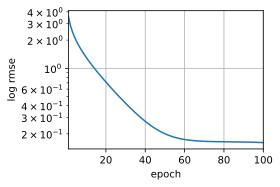

In [14]:
"Prediction"

lr = 5.1
wd = 0
num_epochs = 100
batch_size = 64
net = get_net()

train_ls, _ = train(net, train_features, train_labels, None, None, num_epochs, lr, wd, batch_size)
d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
print(f'训练log rmse: {float(train_ls[-1]):f}')

preds = net(test_features).detach().numpy()
print(preds)